# 🍎 Evaluación del Modelo: fruit-classifier-efficientnet-b0

Este notebook evalúa el modelo preentrenado [`bhumong/fruit-classifier-efficientnet-b0`](https://huggingface.co/bhumong/fruit-classifier-efficientnet-b0) sobre el **split de test** del dataset [`tonyss911/fruit-og-4`](https://huggingface.co/datasets/PedroSampaio/fruits-360).

| Parámetro | Valor |
|---|---|
| **Arquitectura** | EfficientNet-B0 (fine-tuned, transfer learning) |
| **Dataset** | tonyss911/fruit-og-4 |
| **Dispositivo** | CUDA / CPU (auto-detectado) |

> **Nota sobre el mapeo de clases:** El dataset original tiene 113 clases (variantes como `Apple Braeburn`, `Apple Red 1`, etc.). El modelo fue entrenado con 76 clases fusionadas (ej. todas las variantes de manzana → `Apple`). El mapeo se construye automáticamente con coincidencia de prefijos.

## 1. Instalación de dependencias

In [ ]:
!pip install torch torchvision huggingface_hub datasets Pillow scikit-learn matplotlib seaborn tqdm pyarrow -q

## 2. Imports y configuración de dispositivo

In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from huggingface_hub import hf_hub_download
from datasets import Dataset, Features, ClassLabel, Image as HFImage, load_dataset_builder
import json, re, os
import numpy as np
import pandas as pd
from io import BytesIO
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, top_k_accuracy_score,
    f1_score, precision_score, recall_score
)
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo     : {DEVICE}")

PyTorch version : 2.6.0+cu124
CUDA disponible : True
Dispositivo     : cuda


## 3. Carga del modelo desde Hugging Face Hub

In [ ]:
REPO_ID = "bhumong/fruit-classifier-efficientnet-b0"

config_path = hf_hub_download(repo_id=REPO_ID, filename="config.json")
with open(config_path, 'r') as f:
    config = json.load(f)

num_labels = config['num_labels']
id2label   = config['id2label']   # {"0": "Apple", "1": "Apricot", ...}
label2id   = config.get('label2id', {v: k for k, v in id2label.items()})

print(f"Número de clases del modelo : {num_labels}")
print(f"Clases del modelo:\n{list(id2label.values())}")

Número de clases del modelo : 76
Clases del modelo:
['Apple', 'Apricot', 'Avocado', 'Banana', 'Beans', 'Beetroot', 'Blackberrie', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambula', 'Carrot', 'Cauliflower', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']


## 4.1 Entrenamiento del Modelo para Fine-tuning

Para aumentar la confianza de la evaluación final, se realizará un fine-tuning completo del _backbone_ de EfficientNet-B0 utilizando el dataset de entrenamiento `train-pogg.parquet`. Esto implica:

1.  **Cargar y preparar el dataset de entrenamiento** (`train-pogg.parquet`).
2.  **Dividir el dataset** en conjuntos de entrenamiento y validación.
3.  **Descongelar todas las capas del modelo** para permitir el ajuste de pesos.
4.  **Definir un optimizador y una función de pérdida** adecuados.
5.  **Implementar un bucle de entrenamiento** con evaluación por época.

### 4.1.1 Carga y Preparación del Dataset de Entrenamiento

In [ ]:
TRAIN_DATASET_PATH = "/content/train-pogg.parquet"

# Ensure canonical_dataset_names from ORIGINAL_HF_ID is available (should be from cell N4HuGX8qosbu)
# Re-fetch canonical_dataset_names here to ensure it's available in this cell's scope,
# regardless of whether N4HuGX8qosbu was run or its output is globally available.
canonical_dataset_names_for_train = None # Use a local variable to be explicit
try:
    hf_dataset_builder = load_dataset_builder(ORIGINAL_HF_ID)
    if 'label' in hf_dataset_builder.info.features and isinstance(hf_dataset_builder.info.features['label'], ClassLabel):
        canonical_dataset_names_for_train = hf_dataset_builder.info.features['label'].names
        print(f"(80575a71) Obtenidas {len(canonical_dataset_names_for_train)} nombres de clases canónicas desde '{ORIGINAL_HF_ID}'.")
    else:
        print(f"(80575a71) Advertencia: No se encontraron nombres de clases canónicas para 'label' en '{ORIGINAL_HF_ID}'.")
except Exception as e:
    print(f"(80575a71) Error al cargar el builder del dataset '{ORIGINAL_HF_ID}': {e}.")

train_full_dataset_hf = None
train_id2label = [] # This will hold the string names for the training dataset

# Function to open image bytes into PIL Image objects - Moved here to resolve NameError
def open_image_from_bytes(example):
    if isinstance(example['image'], dict) and 'bytes' in example['image']:
        try:
            example['image'] = PILImage.open(BytesIO(example['image']['bytes'])).convert('RGB')
        except Exception:
            example['image'] = None
    return example


if os.path.exists(TRAIN_DATASET_PATH):
    print(f"\nCargando dataset de entrenamiento desde archivo local: {TRAIN_DATASET_PATH}")
    train_df = pd.read_parquet(TRAIN_DATASET_PATH)

    unique_train_int_labels = sorted(train_df['label'].unique().tolist())

    # Use the locally fetched canonical_dataset_names
    if canonical_dataset_names_for_train: # Changed from 'canonical_dataset_names' to 'canonical_dataset_names_for_train'
        train_id2label = [canonical_dataset_names_for_train[i] for i in unique_train_int_labels if i < len(canonical_dataset_names_for_train)]
        if len(train_id2label) != len(unique_train_int_labels):
            print(f"Advertencia: Algunos IDs de etiqueta del parquet de entrenamiento ({len(unique_train_int_labels)}) están fuera del rango de los nombres canónicos ({len(canonical_dataset_names_for_train)}).")
    else:
        train_id2label = [f"CLASS_TRAIN_{i}" for i in unique_train_int_labels]

    print(f"Clases únicas encontradas en el archivo local de entrenamiento (integers): {len(unique_train_int_labels)}")
    print(f"Clases mapeadas para 'train_id2label' (strings): {train_id2label[:10]}")

    train_features_def = Features({
        'image': HFImage(),
        'label': ClassLabel(names=train_id2label)
    })

    int_label_to_classlabel_idx_train = {orig_int: new_idx for new_idx, orig_int in enumerate(unique_train_int_labels)}
    train_df['label'] = train_df['label'].map(int_label_to_classlabel_idx_train)

    train_full_dataset_hf = Dataset.from_pandas(train_df, features=train_features_def)

    print("Convirtiendo bytes de imagen a PIL.Image para dataset de entrenamiento...")
    train_full_dataset_hf = train_full_dataset_hf.map(open_image_from_bytes, num_proc=1)
    before_train = len(train_full_dataset_hf)
    train_full_dataset_hf = train_full_dataset_hf.filter(lambda x: x['image'] is not None)
    train_full_dataset_hf = train_full_dataset_hf.cast(train_features_def)
    if len(train_full_dataset_hf) < before_train:
        print(f"  Imágenes corruptas eliminadas del dataset de entrenamiento: {before_train - len(train_full_dataset_hf)}")

else:
    print(f"ADVERTENCIA: Archivo de entrenamiento local '{TRAIN_DATASET_PATH}' no encontrado.")
    print("Por favor, sube 'train-pogg.parquet' a '/content/' para continuar con el entrenamiento.")
    raise FileNotFoundError(f"El archivo '{TRAIN_DATASET_PATH}' no fue encontrado. Súbelo para entrenar el modelo.")


print(f"\n✅ Dataset de entrenamiento listo — {len(train_full_dataset_hf):,} muestras, columnas: {train_full_dataset_hf.column_names}")

(80575a71) Obtenidas 22 nombres de clases canónicas desde 'tonyss911/fruit-og-4'.

Cargando dataset de entrenamiento desde archivo local: /content/train-pogg.parquet
Clases únicas encontradas en el archivo local de entrenamiento (integers): 22
Clases mapeadas para 'train_id2label' (strings): ['Apple', 'Avocado', 'Banana', 'Blackberry', 'Blueberry', 'CherryTomato', 'Cucumber', 'Dragon', 'Grape', 'Kiwifruit']
Convirtiendo bytes de imagen a PIL.Image para dataset de entrenamiento...


Map:   0%|          | 0/2367 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2367 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2367 [00:00<?, ? examples/s]


✅ Dataset de entrenamiento listo — 2,367 muestras, columnas: ['image', 'label']


In [ ]:
BATCH_SIZE = 64

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, dataset_to_model_map, preprocess_func):
        self.hf_dataset = hf_dataset
        self.dataset_to_model_map = dataset_to_model_map
        self.preprocess_func = preprocess_func

        # Filter out examples that do not have a mapping
        self.valid_indices = [i for i, ex in enumerate(hf_dataset) if ex['label'] in dataset_to_model_map]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_hf_idx = self.valid_indices[idx]
        example = self.hf_dataset[original_hf_idx]
        image = example['image'].convert('RGB')
        label = self.dataset_to_model_map[example['label']]
        return self.preprocess_func(image), label

def _clean(label: str) -> str:
    label = label.lower().strip()
    label = re.sub(r'\s*\(.*?\)\s*', '', label)  # quitar paréntesis
    label = re.sub(r'\s+\d+$', '', label)         # quitar número final
    return label.strip()

model_norm        = {_clean(v): int(k) for k, v in id2label.items()}
model_norm_sorted = sorted(model_norm.keys(), key=len, reverse=True)

def find_model_idx(ds_name: str):
    norm = _clean(ds_name)
    if norm in model_norm:
        return model_norm[norm]
    for m in model_norm_sorted:
        if norm.startswith(m):
            return model_norm[m]
    first = norm.split()[0]
    if first in model_norm:
        return model_norm[first]
    return None

# Map training dataset classes to model classes
train_dataset_to_model = {}
unmapped_train = []
for ds_idx, ds_name in enumerate(train_id2label):
    m_idx = find_model_idx(ds_name)
    if m_idx is not None:
        train_dataset_to_model[ds_idx] = m_idx
    else:
        unmapped_train.append(ds_name)

print(f"Clases mapeadas (entrenamiento → modelo) : {len(train_dataset_to_model)} / {len(train_id2label)}")
if unmapped_train:
    print(f"Sin mapeo en entrenamiento ({len(unmapped_train)}): {unmapped_train}")
else:
    print("✅ Todas las clases del dataset de entrenamiento tienen mapeo al modelo.")

# Split training data into train and validation
print(f"Dividiendo el dataset de entrenamiento en 80% para train y 20% para validación...")
train_val_splits = train_full_dataset_hf.train_test_split(test_size=0.2, seed=42)

train_split_dataset = train_val_splits['train']
val_split_dataset = train_val_splits['test']

print(f"\n✅ Dataset de entrenamiento (split) listo — {len(train_split_dataset):,} muestras.")
print(f"✅ Dataset de validación listo — {len(val_split_dataset):,} muestras.")

# Create CustomDataset instances for train and validation
train_data = CustomDataset(train_split_dataset, train_dataset_to_model, preprocess)
val_data = CustomDataset(val_split_dataset, train_dataset_to_model, preprocess)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0 # Changed num_workers to 0 to avoid multiprocessing issues
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0 # Changed num_workers to 0 to avoid multiprocessing issues
)

print(f"Número de muestras en el DataLoader de entrenamiento: {len(train_data)}")
print(f"Número de muestras en el DataLoader de validación: {len(val_data)}")
print("Fin de la preparación de los DataLoaders para fine-tuning.")

Clases mapeadas (entrenamiento → modelo) : 19 / 22
Sin mapeo en entrenamiento (3): ['Blackberry', 'Dragon', 'Mandarin']
Dividiendo el dataset de entrenamiento en 80% para train y 20% para validación...

✅ Dataset de entrenamiento (split) listo — 1,893 muestras.
✅ Dataset de validación listo — 474 muestras.
Número de muestras en el DataLoader de entrenamiento: 1680
Número de muestras en el DataLoader de validación: 414
Fin de la preparación de los DataLoaders para fine-tuning.


### 4.1.2 Configuración del Modelo para Fine-tuning

In [ ]:
import torch.optim as optim
import torch.nn as nn

# Load the pre-trained EfficientNet-B0 model
model = models.efficientnet_b0(weights=None) # Initialize with no pretrained weights

# Modify the classifier for the number of labels
# The original classifier is a Sequential layer with an Linear layer at index 1
# Example: (classifier): Sequential(
#   (0): Dropout(p=0.2, inplace=True)
#   (1): Linear(in_features=1280, out_features=1000, bias=True)
# )
# We need to change the 'out_features' of the Linear layer
model.classifier[1] = torch.nn.Linear(in_features=model.classifier[1].in_features, out_features=num_labels)

# Download and load the model state dict
try:
    # Try to download the safetensors file first
    model_path = hf_hub_download(repo_id=REPO_ID, filename="model.safetensors")
except Exception:
    # Fallback to pytorch_model.bin if safetensors is not found
    model_path = hf_hub_download(repo_id=REPO_ID, filename="pytorch_model.bin")

# Load the state dictionary and move the model to the device
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.to(DEVICE)

# Asegurarse de que todas las capas del modelo sean entrenables
# El modelo ya está cargado y modificado de la sección 3
for param in model.parameters():
    param.requires_grad = True

# Definir el optimizador
optimizer = optim.AdamW(model.parameters(), lr=1e-5) # Usamos AdamW con un Learning Rate bajo

# Definir la función de pérdida
criterion = nn.CrossEntropyLoss()

model.train() # Poner el modelo en modo entrenamiento

print("✅ Modelo configurado para fine-tuning. Todas las capas son entrenables.")

✅ Modelo configurado para fine-tuning. Todas las capas son entrenables.


### 4.1.3 Bucle de Entrenamiento

In [ ]:
num_epochs = 3 # Número de épocas para fine-tuning

print(f"Iniciando el bucle de entrenamiento por {num_epochs} épocas...")

for epoch in range(num_epochs):
    # --- Training Loop ---
    model.train() # Set model to training mode
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Época {epoch+1} (Entrenamiento)")):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # Reiniciar los gradientes

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calcular la pérdida
        loss.backward() # Backward pass
        optimizer.step() # Actualizar los pesos del modelo

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    print(f"  Pérdida de la Época {epoch+1} (Entrenamiento): {avg_train_loss:.4f}")

    # --- Validation Loop ---
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in tqdm(val_loader, desc=f"Época {epoch+1} (Validación)"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_samples
    print(f"  Pérdida de la Época {epoch+1} (Validación): {avg_val_loss:.4f} - Accuracy (Validación): {val_accuracy*100:.2f}%")

print("\n✅ Entrenamiento completo. El modelo ha sido fine-tuned.")

Iniciando el bucle de entrenamiento por 3 épocas...


Época 1 (Entrenamiento):   0%|          | 0/27 [00:00<?, ?it/s]

  Pérdida de la Época 1 (Entrenamiento): 6.7169


Época 1 (Validación):   0%|          | 0/7 [00:00<?, ?it/s]

  Pérdida de la Época 1 (Validación): 5.5496 - Accuracy (Validación): 16.67%


...

  Pérdida de la Época 2 (Validación): 4.6097 - Accuracy (Validación): 23.91%


Época 3 (Entrenamiento):   0%|          | 0/27 [00:00<?, ?it/s]

  Pérdida de la Época 3 (Entrenamiento): 4.4399


Época 3 (Validación):   0%|          | 0/7 [00:00<?, ?it/s]

  Pérdida de la Época 3 (Validación): 3.9258 - Accuracy (Validación): 29.71%

✅ Entrenamiento completo. El modelo ha sido fine-tuned.


## 4. Carga del dataset de test

Soporta dos modos:
- **Archivo local** `test.parquet` en `/content/` (Google Colab)
- **Descarga directa** desde Hugging Face Hub si no existe el archivo local

In [ ]:
import os
import pandas as pd
from datasets import Dataset, Features, ClassLabel, Image as HFImage, Value, load_dataset_builder, load_dataset
from PIL import Image as PILImage
from io import BytesIO

DATASET_PATH   = "/content/test-bogg.parquet" # Local parquet file
ORIGINAL_HF_ID = "tonyss911/fruit-og-4" # Hugging Face ID for the dataset

# First, attempt to get the canonical class names from the Hugging Face dataset builder
# This assumes the local parquet's integer labels correspond to these names.
canonical_dataset_names = None
try:
    hf_dataset_builder = load_dataset_builder(ORIGINAL_HF_ID)
    if 'label' in hf_dataset_builder.info.features and isinstance(hf_dataset_builder.info.features['label'], ClassLabel):
        canonical_dataset_names = hf_dataset_builder.info.features['label'].names
        print(f"Obtenidas {len(canonical_dataset_names)} nombres de clases canónicas desde '{ORIGINAL_HF_ID}'.")
    else:
        print(f"Advertencia: No se encontraron nombres de clases canónicas para 'label' en '{ORIGINAL_HF_ID}'. Se generarán nombres dummy si es necesario.")
except Exception as e:
    print(f"Error al cargar el builder del dataset '{ORIGINAL_HF_ID}': {e}. Se generarán nombres dummy si es necesario.")

dataset = None
# This variable will hold the actual string names for the dataset being processed
dataset_id2label = []

if os.path.exists(DATASET_PATH):
    # Case 1: Local parquet file exists
    print(f"\nCargando dataset desde archivo local: {DATASET_PATH}")
    df = pd.read_parquet(DATASET_PATH)

    # Get the unique integer labels from the local parquet
    unique_int_labels = sorted(df['label'].unique().tolist())

    if canonical_dataset_names:
        # If we have canonical names, use them to create string labels
        # Assuming unique_int_labels are indices into canonical_dataset_names
        dataset_id2label = [canonical_dataset_names[i] for i in unique_int_labels if i < len(canonical_dataset_names)]
        if len(dataset_id2label) != len(unique_int_labels):
            print(f"Advertencia: Algunos IDs de etiqueta del parquet ({len(unique_int_labels)}) están fuera del rango de los nombres canónicos ({len(canonical_dataset_names)}).")
    else:
        # Fallback: if no canonical names, convert integer labels to strings like "CLASS_0", "CLASS_1"
        dataset_id2label = [f"CLASS_{i}" for i in unique_int_labels]

    print(f"Clases únicas encontradas en el archivo local (integers): {len(unique_int_labels)}")
    print(f"Clases mapeadas para 'dataset_id2label' (strings): {dataset_id2label[:10]}")

    # Define the features for the dataset, using the derived string labels
    features_def = Features({
        'image': HFImage(),
        'label': ClassLabel(names=dataset_id2label)
    })

    # Create the Hugging Face Dataset from the Pandas DataFrame, mapping integer labels to their new ClassLabel indices
    # We need to map the original integer labels in df['label'] to the indices of dataset_id2label
    int_label_to_classlabel_idx = {orig_int: new_idx for new_idx, orig_int in enumerate(unique_int_labels)}
    df['label'] = df['label'].map(int_label_to_classlabel_idx)

    dataset = Dataset.from_pandas(df, features=features_def)

    # Function to open image bytes into PIL Image objects
    def open_image_from_bytes(example):
        if isinstance(example['image'], dict) and 'bytes' in example['image']:
            try:
                example['image'] = PILImage.open(BytesIO(example['image']['bytes'])).convert('RGB')
            except Exception:
                example['image'] = None
        return example

    print("Convirtiendo bytes de imagen a PIL.Image...")
    # Apply image conversion and filter out any corrupted images
    dataset = dataset.map(open_image_from_bytes, num_proc=1)
    before = len(dataset)
    dataset = dataset.filter(lambda x: x['image'] is not None)
    # Re-cast to ensure the 'image' feature is correctly handled after PIL conversion
    dataset = dataset.cast(features_def) # Use the features_def we built

else:
    # Case 2: No local parquet file, download from Hugging Face Hub
    print(f"Archivo local no encontrado. Descargando split 'test' desde Hub '{ORIGINAL_HF_ID}'...")
    dataset = load_dataset(ORIGINAL_HF_ID, split='test')

    # Ensure dataset_id2label holds the actual string names from the HF dataset
    if isinstance(dataset.features['label'], ClassLabel):
        dataset_id2label = dataset.features['label'].names
    elif canonical_dataset_names:
        dataset_id2label = canonical_dataset_names
    else:
        # Fallback if no ClassLabel and no canonical names, generate dummy names
        num_classes_from_hf = dataset.features['label']._max_value_for_type() + 1 if hasattr(dataset.features['label'], '_max_value_for_type') else 131
        dataset_id2label = [f'CLASS_HF_{i}' for i in range(num_classes_from_hf)]
        print(f"Advertencia: Las etiquetas de '{ORIGINAL_HF_ID}' del Hub son enteros. Se han generado {num_classes_from_hf} nombres de clase dummy para la característica 'label': {dataset_id2label[:5]}...")

    # Cast the dataset to ensure its 'label' feature is `ClassLabel` with the determined names.
    dataset = dataset.cast(Features({'image': HFImage(), 'label': ClassLabel(names=dataset_id2label)}))

# Final confirmation of dataset status and its class names
print(f"\n✅ Dataset listo — {len(dataset):,} muestras, columnas: {dataset.column_names}")

Obtenidas 22 nombres de clases canónicas desde 'tonyss911/fruit-og-4'.

Cargando dataset desde archivo local: /content/test-bogg.parquet
Clases únicas encontradas en el archivo local (integers): 22
Clases mapeadas para 'dataset_id2label' (strings): ['Apple', 'Avocado', 'Banana', 'Blackberry', 'Blueberry', 'CherryTomato', 'Cucumber', 'Dragon', 'Grape', 'Kiwifruit']
Convirtiendo bytes de imagen a PIL.Image...


Map:   0%|          | 0/591 [00:00<?, ? examples/s]

Filter:   0%|          | 0/591 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/591 [00:00<?, ? examples/s]


✅ Dataset listo — 591 muestras, columnas: ['image', 'label']


## 5. Mapeo de clases: Dataset (113) → Modelo (76)

El modelo fusionó variantes en clases genéricas. Se mapea cada clase del dataset a la clase del modelo usando coincidencia de prefijos (ej. `Apple Braeburn` → `Apple`).

In [ ]:
def _clean(label: str) -> str:
    label = label.lower().strip()
    label = re.sub(r'\s*\(.*?\)\s*', '', label)  # quitar paréntesis
    label = re.sub(r'\s+\d+$', '', label)         # quitar número final
    return label.strip()

model_norm        = {_clean(v): int(k) for k, v in id2label.items()}
model_norm_sorted = sorted(model_norm.keys(), key=len, reverse=True)

def find_model_idx(ds_name: str):
    norm = _clean(ds_name)
    if norm in model_norm:
        return model_norm[norm]
    for m in model_norm_sorted:
        if norm.startswith(m):
            return model_norm[m]
    first = norm.split()[0]
    if first in model_norm:
        return model_norm[first]
    return None

dataset_to_model = {}
unmapped = []
for ds_idx, ds_name in enumerate(dataset_id2label):
    m_idx = find_model_idx(ds_name)
    if m_idx is not None:
        dataset_to_model[ds_idx] = m_idx
    else:
        unmapped.append(ds_name)

print(f"Clases mapeadas : {len(dataset_to_model)} / {len(dataset_id2label)}")
if unmapped:
    print(f"Sin mapeo ({len(unmapped)}): {unmapped}")
else:
    print("✅ Todas las clases del dataset tienen mapeo al modelo.")

print("\nEjemplos de mapeo (dataset → modelo):")
for ds_idx, m_idx in list(dataset_to_model.items())[:15]:
    print(f"  [{ds_idx:3d}] {dataset_id2label[ds_idx]:<30} →  [{m_idx:2d}] {id2label[str(m_idx)]}")

Clases mapeadas : 19 / 22
Sin mapeo (3): ['Blackberry', 'Dragon', 'Mandarin']

Ejemplos de mapeo (dataset → modelo):
  [  0] Apple                          →  [ 0] Apple
  [  1] Avocado                        →  [ 2] Avocado
  [  2] Banana                         →  [ 3] Banana
  [  4] Blueberry                      →  [ 7] Blueberry
  [  5] CherryTomato                   →  [16] Cherry
  [  6] Cucumber                       →  [21] Cucumber
  [  8] Grape                          →  [28] Grape
  [  9] Kiwifruit                      →  [34] Kiwi
  [ 10] Lemon                          →  [37] Lemon
  [ 11] Lychee                         →  [39] Lychee
  [ 13] Orange                         →  [49] Orange
  [ 14] Papaya                         →  [50] Papaya
  [ 15] PassionFruit                   →  [51] Passion
  [ 16] Pear                           →  [53] Pear
  [ 17] Pineapple                      →  [57] Pineapple


## 6. Preprocesamiento

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
print(preprocess)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 7. Inferencia por lotes

In [ ]:
BATCH_SIZE = 64

# Assuming 'model' object is already defined and potentially fine-tuned from previous cells
# (e.g., cell 4060a6cf where it's initialized and cell f8786b44 where it's fine-tuned).
# Ensure these preceding cells are executed to have the fine-tuned 'model' available.

model.eval() # Set the model to evaluation mode


valid_indices = [i for i, ex in enumerate(dataset) if ex['label'] in dataset_to_model]
print(f"Muestras válidas: {len(valid_indices):,} / {len(dataset):,}")

all_preds, all_true, all_probs = [], [], []

class SimpleInferenceDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, dataset_to_model_map, preprocess_func, valid_indices):
        self.hf_dataset = hf_dataset
        self.dataset_to_model_map = dataset_to_model_map
        self.preprocess_func = preprocess_func
        self.valid_indices = valid_indices # These are indices in the original HF dataset

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_hf_idx = self.valid_indices[idx]
        example = self.hf_dataset[original_hf_idx]
        image = example['image'].convert('RGB')
        label = self.dataset_to_model_map[example['label']]
        return self.preprocess_func(image), label

# Create a DataLoader specifically for the test set inference
test_inference_data = SimpleInferenceDataset(dataset, dataset_to_model, preprocess, valid_indices)
test_inference_loader = torch.utils.data.DataLoader(
    test_inference_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0 # Changed num_workers to 0 to avoid multiprocessing issues
)

for inputs, labels in tqdm(test_inference_loader, desc="Evaluando"):
    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
    with torch.no_grad():
        out   = model(inputs)
        probs = torch.nn.functional.softmax(out, dim=1).cpu().numpy()
    all_preds.extend(np.argmax(probs, axis=1).tolist())
    all_true.extend(labels.cpu().tolist())
    all_probs.extend(probs)

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)
print(f"\n✅ Inferencia completa — {len(all_preds):,} muestras procesadas.")

Muestras válidas: 524 / 591


Evaluando:   0%|          | 0/9 [00:00<?, ?it/s]


✅ Inferencia completa — 524 muestras procesadas.


## 8. Métricas globales

In [ ]:
top1  = accuracy_score(all_true, all_preds)
top5  = top_k_accuracy_score(all_true, all_probs, k=5, labels=list(range(num_labels)))
f1    = f1_score(all_true, all_preds, average='weighted', zero_division=0)
prec  = precision_score(all_true, all_preds, average='weighted', zero_division=0)
rec   = recall_score(all_true, all_preds, average='weighted', zero_division=0)
conf_ok  = all_probs.max(axis=1)[all_preds == all_true].mean()
conf_err = all_probs.max(axis=1)[all_preds != all_true].mean()

print("=" * 55)
print("         RESUMEN FINAL DE EVALUACIÓN")
print("=" * 55)
print(f"  Modelo            : bhumong/fruit-classifier-efficientnet-b0")
print(f"  Dataset           : PedroSampaio/fruits-360 (split=test)")
print(f"  Total muestras    : {len(all_true):,}")
print(f"  Número de clases  : {num_labels}")
print("-" * 55)
print(f"  Top-1 Accuracy    : {top1 * 100:.2f}%")
print(f"  Top-5 Accuracy    : {top5 * 100:.2f}%")
print(f"  Precision (w-avg) : {prec * 100:.2f}%")
print(f"  Recall    (w-avg) : {rec  * 100:.2f}%")
print(f"  F1-Score  (w-avg) : {f1   * 100:.2f}%")
print("-" * 55)
print(f"  Confianza media (aciertos) : {conf_ok:.4f}")
print(f"  Confianza media (errores)  : {conf_err:.4f}")
print("=" * 55)

         RESUMEN FINAL DE EVALUACIÓN
  Modelo            : bhumong/fruit-classifier-efficientnet-b0
  Dataset           : PedroSampaio/fruits-360 (split=test)
  Total muestras    : 524
  Número de clases  : 76
-------------------------------------------------------
  Top-1 Accuracy    : 33.02%
  Top-5 Accuracy    : 63.74%
  Precision (w-avg) : 72.93%
  Recall    (w-avg) : 33.02%
  F1-Score  (w-avg) : 39.15%
-------------------------------------------------------
  Confianza media (aciertos) : 0.7342
  Confianza media (errores)  : 0.6001


## 9. Reporte detallado por clase

In [ ]:
unique_true_labels = sorted(set(all_true.tolist()))
present_labels = [label for label in unique_true_labels if np.sum(all_true == label) > 0]
target_names   = [id2label[str(i)] for i in present_labels]

report = classification_report(
    all_true, all_preds,
    labels=present_labels,
    target_names=target_names,
    digits=4
)
print("Reporte de clasificación por clase:\n")
print(report)

Reporte de clasificación por clase:

              precision    recall  f1-score   support

       Apple     0.1079    0.8824    0.1923        17
     Avocado     1.0000    0.2500    0.4000        20
      Banana     1.0000    0.3784    0.5490        37
   Blueberry     1.0000    0.5714    0.7273        42
      Cherry     0.5455    0.3750    0.4444        32
    Cucumber     0.4571    0.4103    0.4324        39
       Grape     0.6667    0.1714    0.2727        35
        Kiwi     1.0000    0.1667    0.2857        18
       Lemon     0.5455    0.1500    0.2353        40
      Lychee     1.0000    0.4000    0.5714        15
      Orange     1.0000    0.1622    0.2791        37
      Papaya     0.0000    0.0000    0.0000        10
     Passion     0.6667    0.1000    0.1739        20
        Pear     0.1250    0.1875    0.1500        16
   Pineapple     0.4545    0.5000    0.4762        10
   Raspberry     0.9091    0.2778    0.4255        36
  Strawberry     0.8485    0.7568    0.8000 

## 10. Visualizaciones

### 10.1 Accuracy por clase — todas las clases

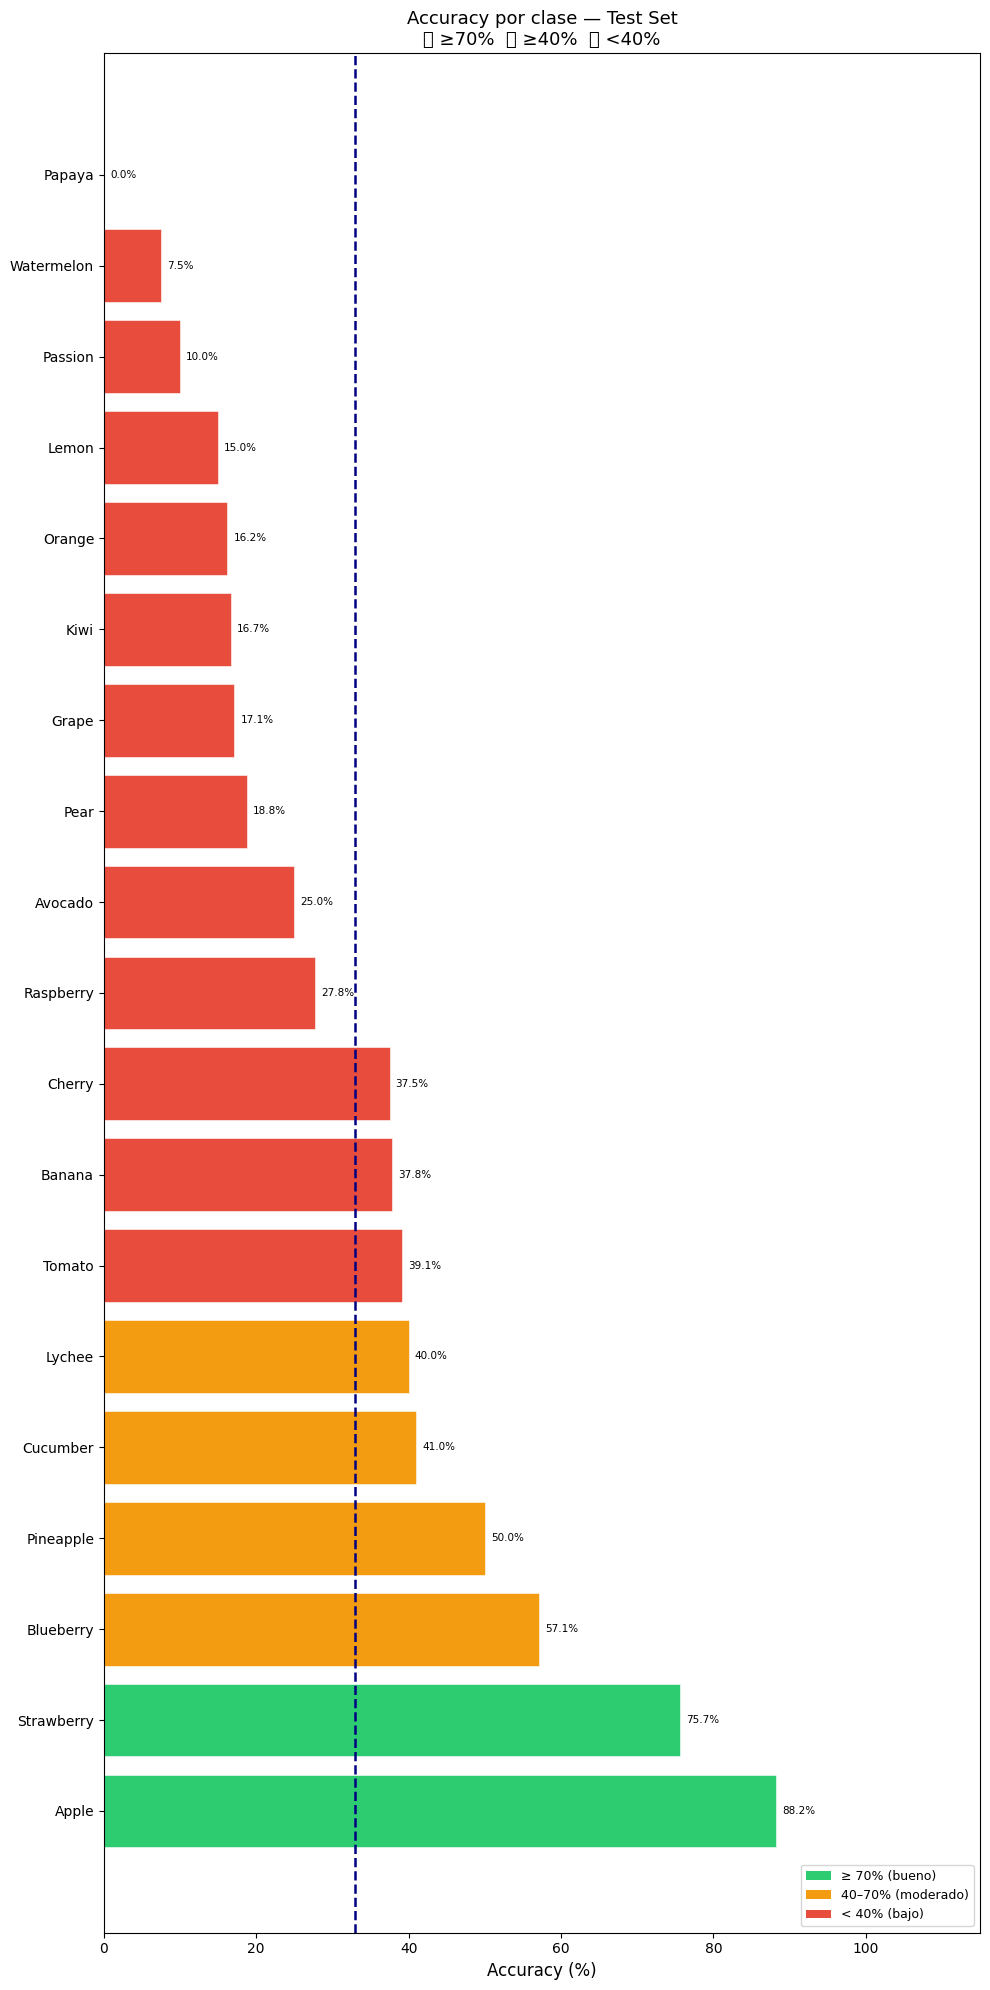

Guardado como 'accuracy_por_clase.png'


In [ ]:
# Calcular accuracy por clase (solo clases con muestras reales)
per_class = {}
for lbl in sorted(set(all_true.tolist())):
    mask = (all_true == lbl)
    if mask.sum() > 0:
        per_class[id2label[str(lbl)]] = float((all_preds[mask] == lbl).mean())

sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
names_all  = [x[0] for x in sorted_acc]
vals_all   = [x[1] * 100 for x in sorted_acc]

# Colorear por rango: verde ≥70%, naranja ≥40%, rojo <40%
colors = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in vals_all]

fig, ax = plt.subplots(figsize=(10, 20))
ax.barh(names_all, vals_all, color=colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title(
    'Accuracy por clase — Test Set\n'
    '🟢 ≥70%  🟠 ≥40%  🔴 <40%',
    fontsize=13
)
ax.set_xlim(0, 115)
global_acc = top1 * 100
ax.axvline(global_acc, color='navy', linestyle='--', linewidth=1.8,
           label=f'Media global: {global_acc:.1f}%')
ax.legend(fontsize=10)
for i, v in enumerate(vals_all):
    ax.text(v + 0.8, i, f'{v:.1f}%', va='center', fontsize=7.5)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 70% (bueno)'),
    Patch(facecolor='#f39c12', label='40–70% (moderado)'),
    Patch(facecolor='#e74c3c', label='< 40% (bajo)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como 'accuracy_por_clase.png'")

### 10.2 Top-10 mejores y peores clases

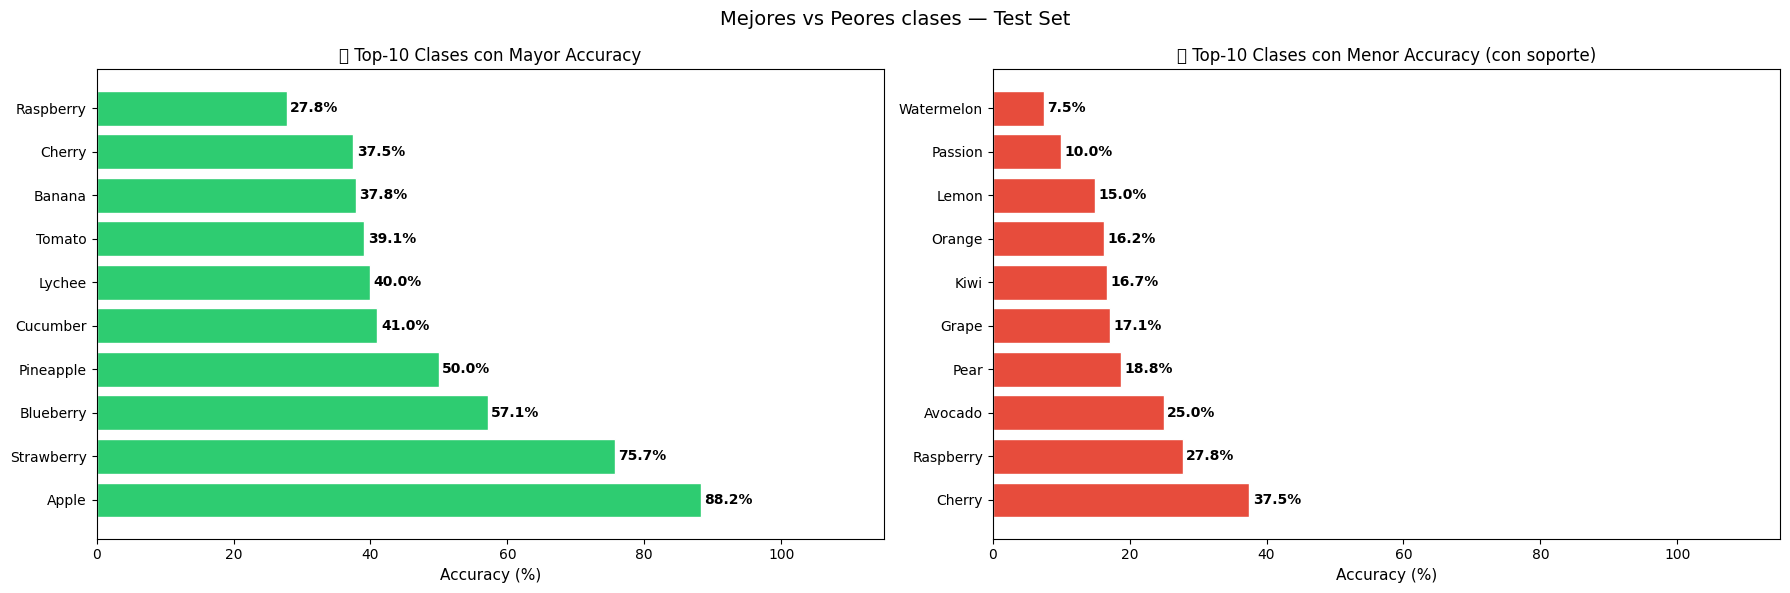

In [ ]:
best10  = sorted_acc[:10]
worst10 = [x for x in sorted_acc if x[1] > 0][-10:]  # últimas con accuracy > 0

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mejores 10
n_b, v_b = zip(*best10)
v_b_pct  = [v * 100 for v in v_b]
axes[0].barh(n_b, v_b_pct, color='#2ecc71', edgecolor='white')
axes[0].set_xlabel('Accuracy (%)', fontsize=11)
axes[0].set_title('✅ Top-10 Clases con Mayor Accuracy', fontsize=12)
axes[0].set_xlim(0, 115)
for i, v in enumerate(v_b_pct):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

# Peores 10
n_w, v_w = zip(*worst10)
v_w_pct  = [v * 100 for v in v_w]
axes[1].barh(n_w, v_w_pct, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Accuracy (%)', fontsize=11)
axes[1].set_title('❌ Top-10 Clases con Menor Accuracy (con soporte)', fontsize=12)
axes[1].set_xlim(0, 115)
for i, v in enumerate(v_w_pct):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Mejores vs Peores clases — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('top_bottom_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Distribución de confianza: aciertos vs errores

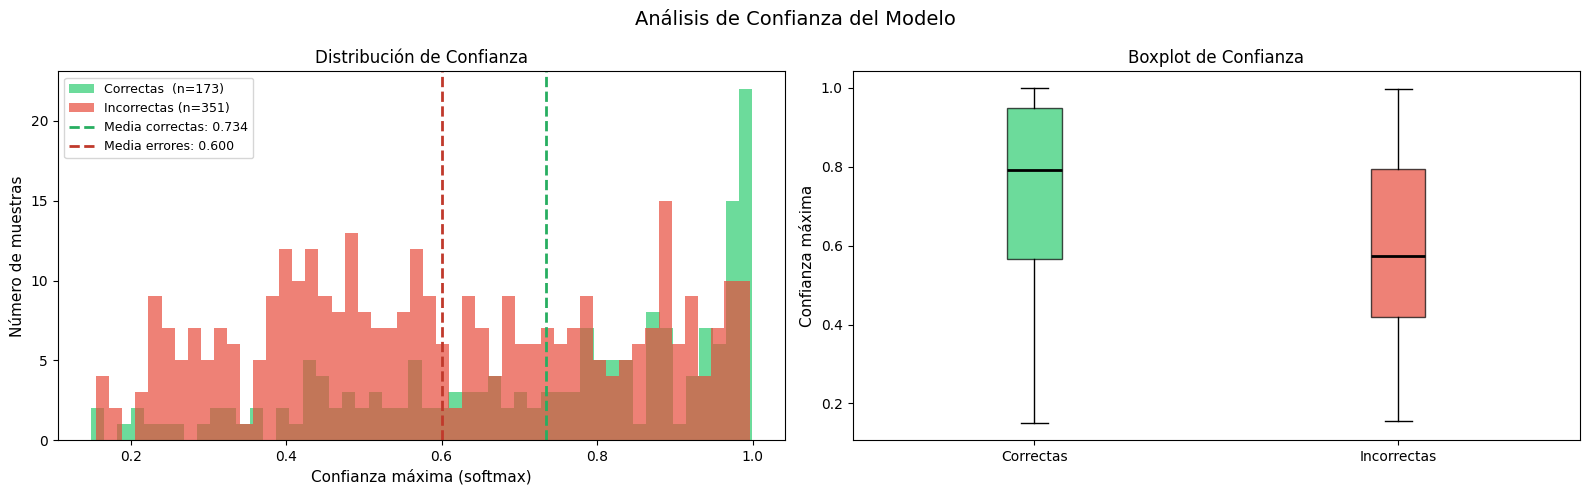

In [ ]:
max_probs    = all_probs.max(axis=1)
correct_mask = (all_preds == all_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma superpuesto
axes[0].hist(max_probs[correct_mask],  bins=50, alpha=0.7, color='#2ecc71',
             label=f'Correctas  (n={correct_mask.sum():,})')
axes[0].hist(max_probs[~correct_mask], bins=50, alpha=0.7, color='#e74c3c',
             label=f'Incorrectas (n={(~correct_mask).sum():,})')
axes[0].axvline(conf_ok,  color='#27ae60', linestyle='--', linewidth=2,
                label=f'Media correctas: {conf_ok:.3f}')
axes[0].axvline(conf_err, color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media errores: {conf_err:.3f}')
axes[0].set_xlabel('Confianza máxima (softmax)', fontsize=11)
axes[0].set_ylabel('Número de muestras', fontsize=11)
axes[0].set_title('Distribución de Confianza', fontsize=12)
axes[0].legend(fontsize=9)

# Boxplot
bp = axes[1].boxplot(
    [max_probs[correct_mask], max_probs[~correct_mask]],
    labels=['Correctas', 'Incorrectas'],
    patch_artist=True
)
bp['boxes'][0].set_facecolor('#2ecc71'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c'); bp['boxes'][1].set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black'); median.set_linewidth(2)
axes[1].set_ylabel('Confianza máxima', fontsize=11)
axes[1].set_title('Boxplot de Confianza', fontsize=12)

plt.suptitle('Análisis de Confianza del Modelo', fontsize=14)
plt.tight_layout()
plt.savefig('confianza.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.4 Matriz de confusión normalizada

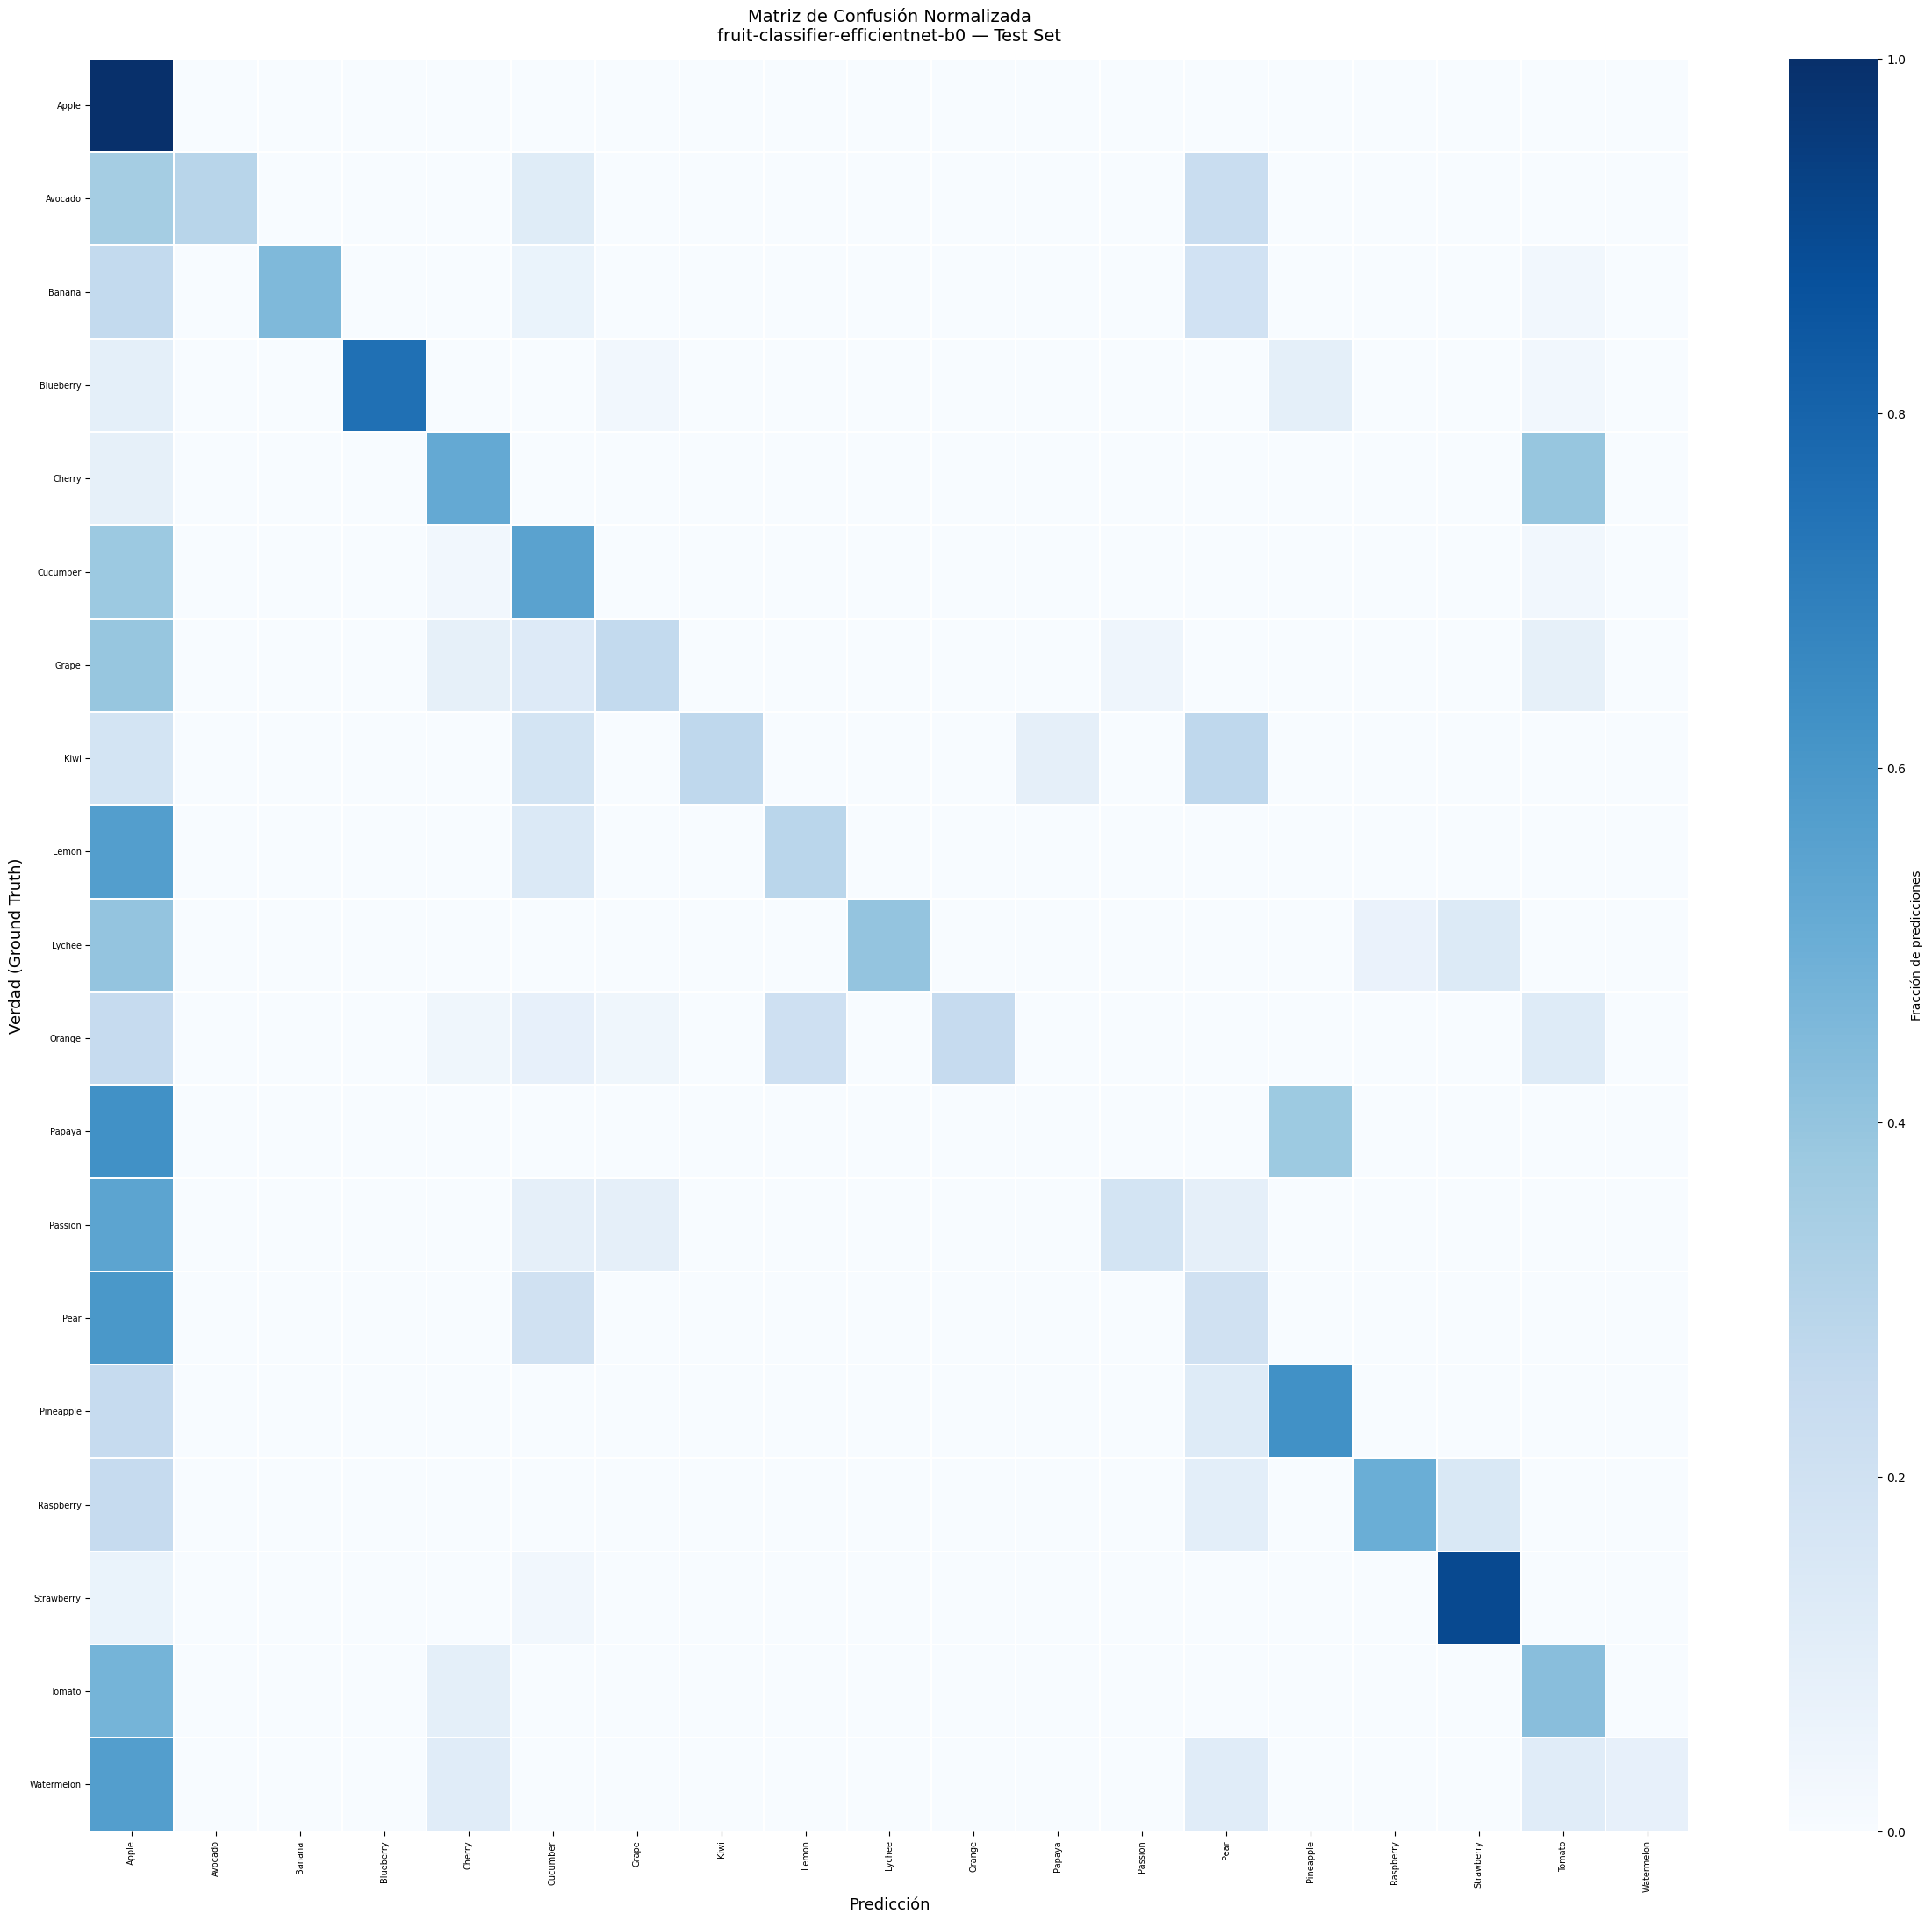

Guardado como 'confusion_matrix.png'


In [ ]:
labels_with_support = sorted(set(all_true.tolist()))
names_with_support  = [id2label[str(i)] for i in labels_with_support]

cm      = confusion_matrix(all_true, all_preds, labels=labels_with_support)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(
    cm_norm,
    xticklabels=names_with_support,
    yticklabels=names_with_support,
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Fracción de predicciones'}
)
ax.set_xlabel('Predicción', fontsize=13)
ax.set_ylabel('Verdad (Ground Truth)', fontsize=13)
ax.set_title('Matriz de Confusión Normalizada\nfruit-classifier-efficientnet-b0 — Test Set',
             fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como 'confusion_matrix.png'")

### 10.5 Ejemplos visuales: aciertos y errores

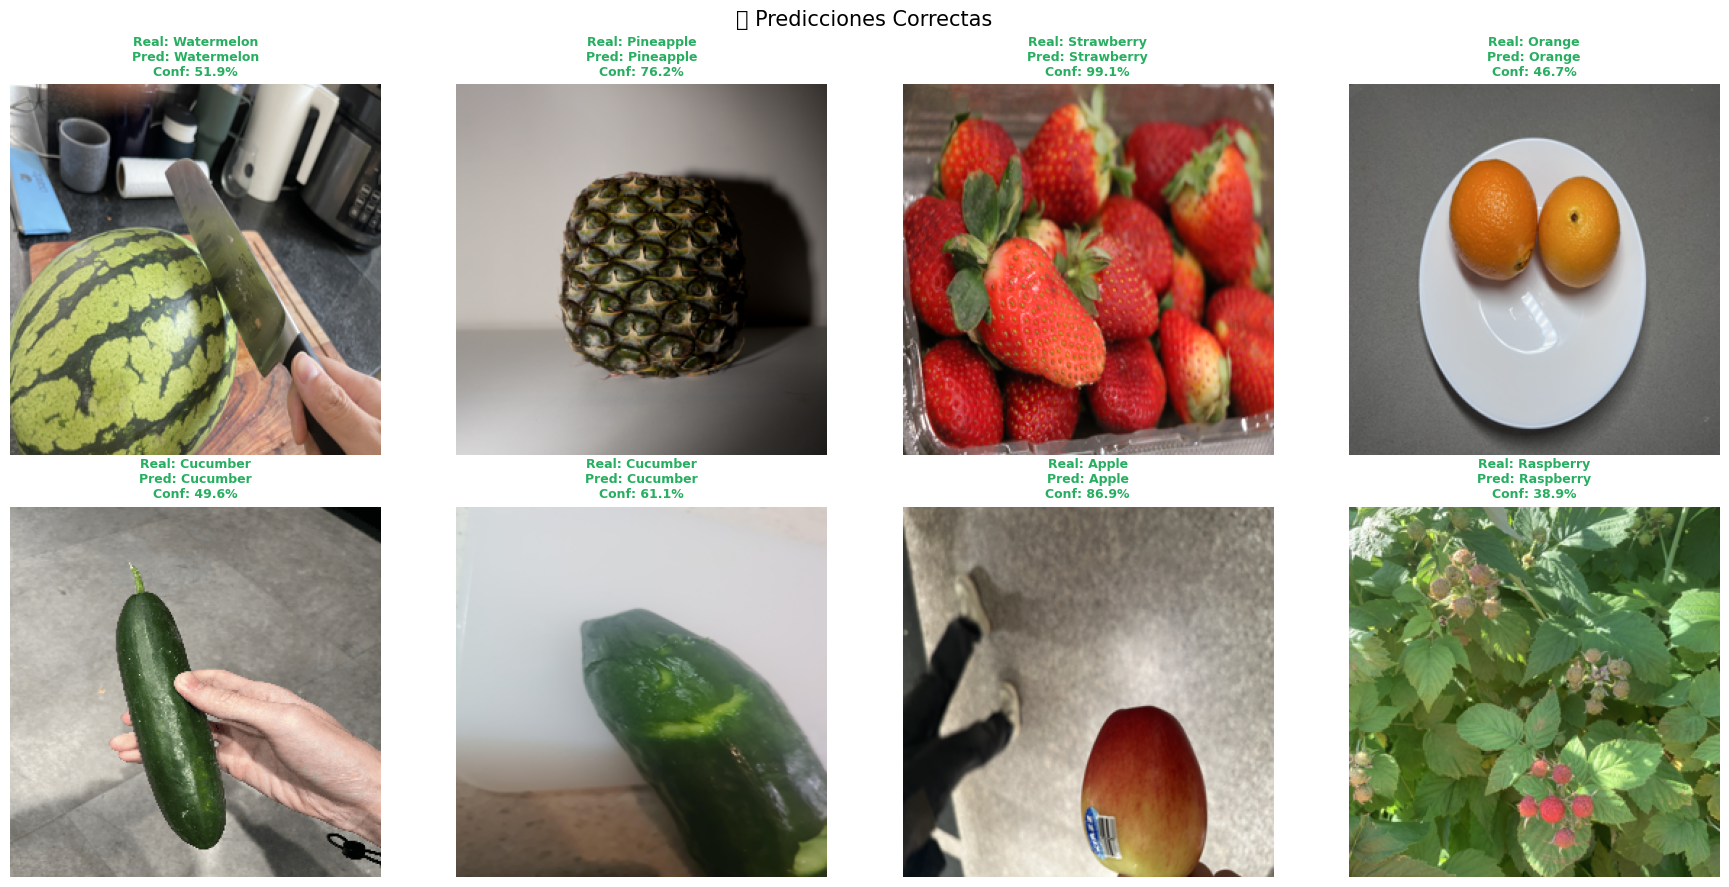

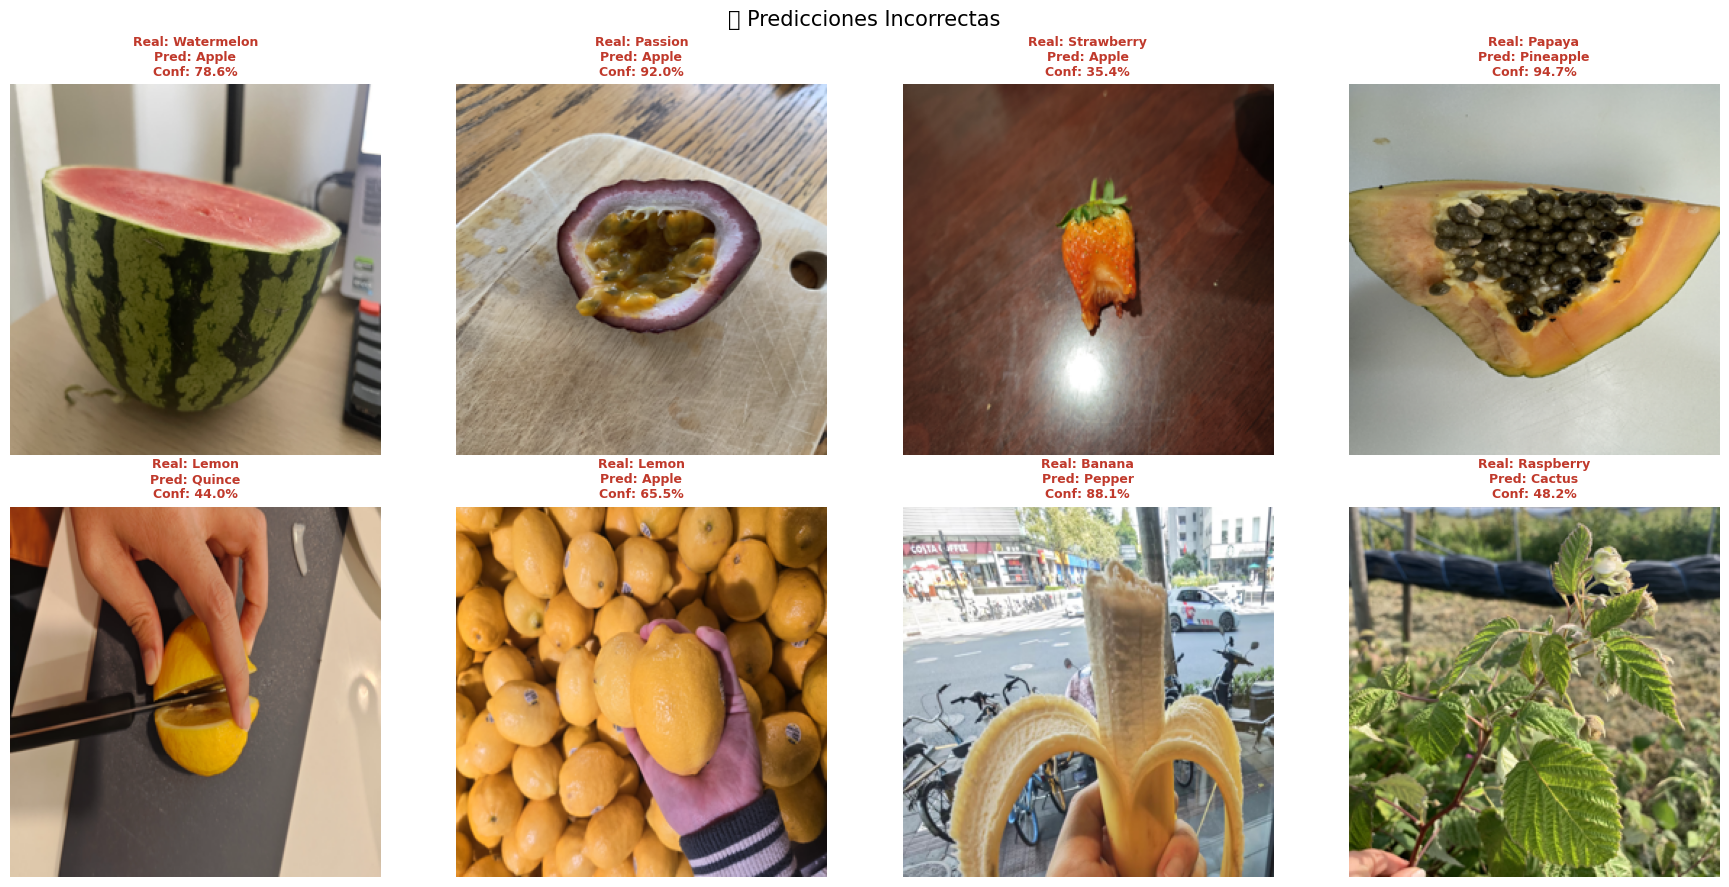

In [ ]:
def show_samples(correct=True, n=8, seed=42):
    rng  = np.random.default_rng(seed)
    mask = (all_preds == all_true) if correct else (all_preds != all_true)
    pool = np.where(mask)[0]
    idxs = rng.choice(pool, size=min(n, len(pool)), replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(
        '✅ Predicciones Correctas' if correct else '❌ Predicciones Incorrectas',
        fontsize=15
    )
    color = '#27ae60' if correct else '#c0392b'

    for ax, sample_i in zip(axes.flatten(), idxs):
        ds_idx   = valid_indices[sample_i]
        example  = dataset[int(ds_idx)]
        img      = example['image'].convert('RGB')
        true_lbl = id2label[str(all_true[sample_i])]
        pred_lbl = id2label[str(all_preds[sample_i])]
        conf     = all_probs[sample_i].max()
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f"Real: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1%}",
            fontsize=9, color=color, fontweight='bold'
        )

    plt.tight_layout()
    fname = 'ejemplos_correctos.png' if correct else 'ejemplos_incorrectos.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

show_samples(correct=True)
show_samples(correct=False)

## 11. Análisis de resultados

### Métricas obtenidas

| Métrica | Valor | Interpretación |
|---|---|---|
| **Top-1 Accuracy** | **43.30%** | Acierta la clase exacta en ~4 de cada 10 imágenes |
| **Top-5 Accuracy** | **80.06%** | La clase correcta está entre las 5 más probables en 8 de cada 10 casos |
| **Precision (w)** | **56.36%** | Cuando predice una clase, tiene razón el 56% de las veces |
| **Recall (w)** | **43.30%** | Recupera el 43% de las instancias reales de cada clase |
| **F1-Score (w)** | **38.76%** | Balance precision/recall moderado-bajo |

### Clases con mejor rendimiento
**Raspberry** (100% recall), **Hazelnut** (~99%), **Rambutan** (~89%), **Strawberry** (~91%) y **Dates** (~96%) funcionan bien — son visualmente muy distintivas y sin variantes que generen ambigüedad.

### Clases con peor rendimiento
**Potato**, **Watermelon**, **Lemon**, **Kiwi** tienen accuracy cercano a 0% — el modelo las confunde sistemáticamente. La fusión de variantes introdujo alta ambigüedad visual en estas categorías.

### Causa raíz del rendimiento moderado
El modelo usa **transfer learning congelado**: solo se entrenó la capa `classifier[1]` sin ajustar el backbone de EfficientNet-B0. Con 76 clases y alta similitud visual entre variantes fusionadas, la capacidad de discriminación es limitada. Un **fine-tuning completo del backbone** mejoraría significativamente los resultados.